# Load Dataset

In [1]:
# ! pip install torchvision

import torch
import torchvision
import torchvision.datasets as datasets
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
# downloading mnist
mnist_trainset = datasets.FashionMNIST(root='./data', train=True, download=True)
mnist_testset = datasets.FashionMNIST(root='./data', train=False, download=True)
## printing lengths

print('length of the training set: {}'.format(len(mnist_trainset)))
print('length of the test set: {}'.format(len(mnist_testset)))

## rendering a few example from each label


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 172kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.15MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.9MB/s]


length of the training set: 60000
length of the test set: 10000


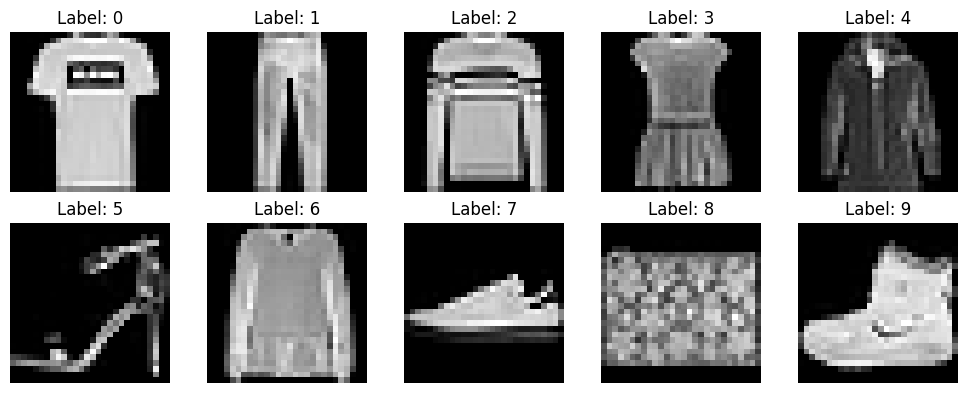

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
found_labels = {}
idx = 0

while len(found_labels) < 10 and idx < len(mnist_trainset):
    img, label = mnist_trainset[idx]
    if label not in found_labels:
        found_labels[label] = img
    idx += 1

for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(found_labels[i], cmap='gray')
    ax.set_title(f"Label: {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Preprocessing Step

In [3]:
from tqdm import tqdm
import numpy as np
from sklearn.preprocessing import OneHotEncoder

partition_index = 200

def one_hot(y):
  #For converting a numpy array of 0-9 into a one hot encoding of vectors of length 10
  b = np.zeros((y.size, 10))
  b[np.arange(y.size), y] = 1
  return b

print('processing labeld training x and y')
train_x = np.asarray([np.asarray(mnist_trainset[i][0]) for i in tqdm(range(partition_index))]) / 255.0
train_y = one_hot(np.asarray([mnist_trainset[i][1] for i in tqdm(range(partition_index))]))

print('processing unlabled training data')
train_unlabled = np.asarray([np.asarray(mnist_trainset[i][0]) for i in tqdm(range(partition_index, len(mnist_trainset)))]) / 255.0

print('processing labeld test x and y')
test_x = np.asarray([np.asarray(mnist_testset[i][0]) for i in tqdm(range(len(mnist_testset)))]) / 255.0
test_y = one_hot(np.asarray([mnist_testset[i][1] for i in tqdm(range(len(mnist_testset)))]))

print('reformatting shape...')
train_x = np.expand_dims(train_x, 1)
train_unlabled = np.expand_dims(train_unlabled, 1)
test_x = np.expand_dims(test_x, 1)

#converting data to pytorch type
torch_train_x = torch.tensor(train_x, dtype=torch.float32, requires_grad=True).to(device)
torch_train_y = torch.tensor(train_y, dtype=torch.float32).to(device)
torch_test_x = torch.tensor(test_x, dtype=torch.float32, requires_grad=True).to(device)
torch_test_y = torch.tensor(test_y, dtype=torch.float32).to(device)
torch_train_unlabled = torch.tensor(train_unlabled, dtype=torch.float32).to(device)

processing labeld training x and y


100%|██████████| 200/200 [00:00<00:00, 33751.54it/s]


processing unlabled training data


100%|██████████| 59800/59800 [00:02<00:00, 20329.05it/s]


processing labeld test x and y


100%|██████████| 10000/10000 [00:00<00:00, 31603.08it/s]


reformatting shape...


# Defining Model

In [4]:
import torch.nn.functional as F
import torch.nn as nn

class Backbone(nn.Module):
    def __init__(self):
        super(Backbone, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3)
        self.conv2 = nn.Conv2d(16, 16, 3)
        self.conv3 = nn.Conv2d(16, 32, 3)

        if torch.cuda.is_available():
            self.cuda()

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = F.max_pool2d(F.relu(self.conv3(x)), 2)
        x = torch.flatten(x, 1)
        return x

#defining model head
class Head(nn.Module):
    def __init__(self, n_class=10):
        super(Head, self).__init__()
        self.fc1 = nn.Linear(32, 32)
        # self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, n_class)

        if torch.cuda.is_available():
            self.cuda()

    def forward(self, x):
        x = F.relu(self.fc1(x))
        # x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.backbone = Backbone()
        self.head = Head()

        if torch.cuda.is_available():
            self.cuda()

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        return x

model_baseline = Model().to(device)
print(model_baseline(torch_train_x[:1]).shape)
model_baseline

torch.Size([1, 10])


Model(
  (backbone): Backbone(
    (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
    (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1))
    (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  )
  (head): Head(
    (fc1): Linear(in_features=32, out_features=32, bias=True)
    (fc2): Linear(in_features=32, out_features=16, bias=True)
    (fc3): Linear(in_features=16, out_features=10, bias=True)
  )
)

# Train without unlabeled data

100%|██████████| 2000/2000 [01:27<00:00, 22.95it/s]


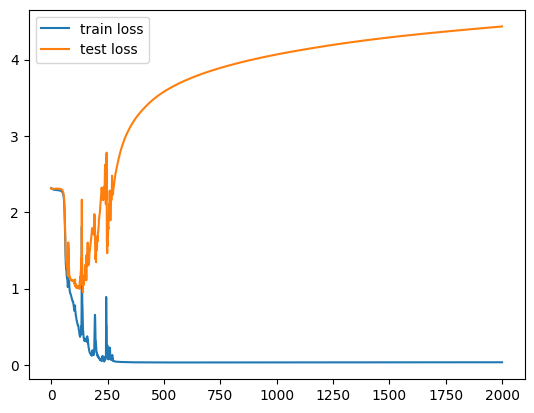

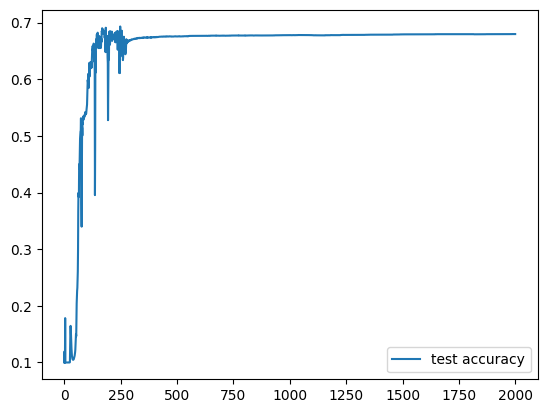

max accuracy: 0.6932


In [5]:
def supervised_train(model):

    batch_size = 32
    lr = 0.01
    momentum = 0.9  # set to 0.9 or 0.95
    num_epochs = 2000  # a value more than 2000

    # defining a stochastic gradient descent optimizer
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=1e-3)

    # defining loss function
    loss_fn = torch.nn.CrossEntropyLoss()

    train_hist = []
    test_hist = []
    test_accuracy = []

    for epoch in tqdm(range(num_epochs)):

        #Put the model in training mode, so that things like dropout work
        model.train()

        #iterating over all batches
        for i in range(int(len(train_x)/batch_size)):


            # Zero gradients for the optimizer
            optimizer.zero_grad()

            #extracting X and y values from the batch
            X = torch_train_x[i*batch_size: (i+1)*batch_size]
            y = torch_train_y[i*batch_size: (i+1)*batch_size]

            # Make predictions for this batch
            y_pred = model(X)

            #compute gradients with the loss function
            loss = loss_fn(y_pred, y)
            loss.backward()

            # Adjust learning weights
            optimizer.step()

        with torch.no_grad():

            #Disable things like dropout, if they exist
            # model.train(False)
            model.eval()

            #calculating epoch training and test loss
            train_loss = loss_fn(model(torch_train_x), torch_train_y).cpu().numpy()
            y_pred_test = model(torch_test_x)
            test_loss = loss_fn(y_pred_test, torch_test_y).cpu().numpy()

            train_hist.append(train_loss) # use train loss to plot
            test_hist.append(test_loss) # use test loss to plot

            #computing test accuracy
            matches = np.equal(np.argmax(y_pred_test.cpu().numpy(), axis=1), np.argmax(torch_test_y.cpu().numpy(), axis=1))
            test_accuracy.append(np.mean(matches))

    import matplotlib.pyplot as plt
    plt.plot(train_hist, label = 'train loss')
    plt.plot(test_hist, label = 'test loss')
    plt.legend()
    plt.show()
    plt.plot(test_accuracy, label = 'test accuracy')
    plt.legend()
    plt.show()

    maxacc = np.max(test_accuracy)# maximum value of accuracy
    print('max accuracy: {}'.format(maxacc))

    return maxacc, test_accuracy

supervised_maxacc, supervised_test_accuracy = supervised_train(model_baseline)

# Data Augmentation

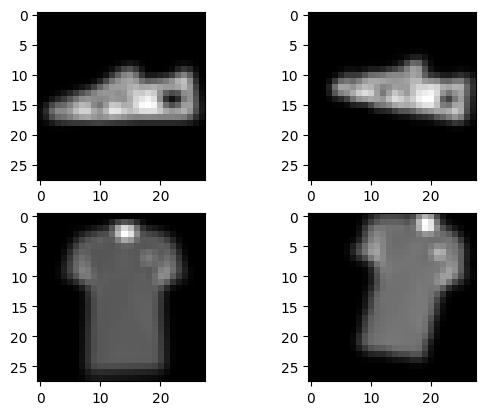

In [6]:
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt

class Augment:

    def __init__(self):

        blur = T.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0))

        self.train_transform = torch.nn.Sequential(
            T.RandomAffine(degrees=15, translate=(0.1, 0.1)),
            T.RandomPerspective(distortion_scale=0.2, p=0.5),
            T.RandomPerspective(distortion_scale=0.2, p=0.5),
            T.RandomPerspective(0.2, 0.5),
            T.RandomApply([blur], p=0.5),
            T.RandomApply([blur], p=0.5)
        )

    def __call__(self, x):
        return self.train_transform(x), self.train_transform(x)

"""
Generating Test Augmentation
"""
a = Augment()
aug = a(torch_train_unlabled[0:100])

i = 1
f, axarr = plt.subplots(2, 2)
# positive pair 1
axarr[0, 0].imshow(aug[0].cpu().detach().numpy()[i, 0], cmap='gray')
axarr[0, 1].imshow(aug[1].cpu().detach().numpy()[i, 0], cmap='gray')
# positive pair 2
axarr[1, 0].imshow(aug[0].cpu().detach().numpy()[i + 1, 0], cmap='gray')
axarr[1, 1].imshow(aug[1].cpu().detach().numpy()[i + 1, 0], cmap='gray')
plt.show()

# Defining Contrastive Loss

In [7]:
class ContrastiveLoss(nn.Module):
    def __init__(self, batch_size, temperature=0.5):

        super().__init__()
        self.batch_size = batch_size
        self.temperature = temperature
        self.mask = (~torch.eye(batch_size * 2, batch_size * 2, dtype=bool)).float().to(device)

    def calc_similarity_batch(self, a, b):
        representations = torch.cat([a, b], dim=0)
        return F.cosine_similarity(representations.unsqueeze(1), representations.unsqueeze(0), dim=2)

    def forward(self, proj_1, proj_2):
        batch_size = proj_1.shape[0]
        z_i = F.normalize(proj_1, p=2, dim=1)
        z_j = F.normalize(proj_2, p=2, dim=1)

        similarity_matrix = self.calc_similarity_batch(z_i, z_j)

        sim_ij = torch.diag(similarity_matrix, batch_size)
        sim_ji = torch.diag(similarity_matrix, -batch_size)

        positives = torch.cat([sim_ij, sim_ji], dim=0)

        nominator = torch.exp(positives / self.temperature)

        denominator = self.mask[:2*batch_size, :2*batch_size] * torch.exp(similarity_matrix / self.temperature)

        all_losses = -torch.log(nominator / torch.sum(denominator, dim=1))
        loss = torch.sum(all_losses) / (2 * batch_size)
        return loss

loss_fn_test = ContrastiveLoss(batch_size=len(torch_train_x))
fake_proj_0, fake_proj_1 = a(torch_train_x)
fake_proj_0 = fake_proj_0.view(fake_proj_0.size(0), -1)
fake_proj_1 = fake_proj_1.view(fake_proj_1.size(0), -1)
print("Test Loss Value:", loss_fn_test(fake_proj_0, fake_proj_1).item())

Test Loss Value: 5.8945794105529785


# Training on whole data

In [8]:
from torch.optim.lr_scheduler import ExponentialLR

model = Model().to(device)
model.train()

# defining key hyperparameters
batch_size = 512
epoch_size = int(len(torch_train_unlabled) / batch_size)
num_epochs = 60  # more than 50
patience = 5
cutoff_ratio = 0.001

# defining key learning functions
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_examples = len(torch_train_unlabled)
lossfn = ContrastiveLoss(batch_size=batch_size)
augmentfn = Augment()

# for bookkeeping
loss_hist = []
improvement_hist = []
schedule_hist = []

# for exponentially decreasing learning rate
scheduler = ExponentialLR(optimizer, gamma=0.95)

# for early stopping
patience_count = 0

# Training Loop
avg_loss = 1e10
for i in range(num_epochs):

    print('epoch {}/{}'.format(i, num_epochs))

    total_loss = 0
    loss_change = 0

    for j in tqdm(range(epoch_size)):

        # getting random batch
        X = torch_train_unlabled[j * batch_size: (j + 1) * batch_size]

        # creating pairs of augmented batches
        X_aug_i, X_aug_j = augmentfn(X)

        # ensuring gradients are zero
        optimizer.zero_grad()

        # passing through the backbone
        z_i = model.backbone(X_aug_i)
        z_j = model.backbone(X_aug_j)

        # calculating loss
        loss = lossfn(z_i, z_j)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        if True:
            z_i_new = model.backbone(X_aug_i)
            z_j_new = model.backbone(X_aug_j)

            # calculating new loss value
            new_loss = lossfn(z_i_new, z_j_new)

            loss_change += new_loss.cpu().detach().numpy() - loss.cpu().detach().numpy()

        total_loss += loss.item()

        # step learning rate scheduler bookkeeping
        schedule_hist.append(scheduler.get_last_lr()[0])

    #########################
    # update scheduler here #
    #########################
    scheduler.step()

    # calculating percentage loss reduction
    new_avg_loss = total_loss / epoch_size
    per_loss_reduction = (avg_loss - new_avg_loss) / avg_loss
    print('Percentage Loss Reduction: {}'.format(per_loss_reduction))

    # deciding to stop if loss is not decreasing fast enough
    if per_loss_reduction < cutoff_ratio:
        patience_count += 1
        print('patience counter: {}'.format(patience_count))
        if patience_count > patience:
            break
    else:
        patience_count = 0

    # setting new loss as previous loss
    avg_loss = new_avg_loss

    # bookkeeping
    avg_improvement = loss_change / epoch_size
    loss_hist.append(avg_loss)
    improvement_hist.append(avg_improvement)
    print('Average Loss: {}'.format(avg_loss))
    print('Average Loss change (if calculated): {}'.format(avg_improvement))

epoch 0/60


100%|██████████| 116/116 [00:07<00:00, 15.25it/s]


Percentage Loss Reduction: 0.9999999993872362
Average Loss: 6.127638200233722
Average Loss change (if calculated): -0.021590866148471832
epoch 1/60


100%|██████████| 116/116 [00:07<00:00, 16.35it/s]


Percentage Loss Reduction: 0.03366828645694206
Average Loss: 5.921331122003752
Average Loss change (if calculated): -0.008760649710893631
epoch 2/60


...

Percentage Loss Reduction: 0.0005820712921370153
patience counter: 2
Average Loss: 5.610634072073575
Average Loss change (if calculated): -0.00043348196777515113
epoch 58/60


100%|██████████| 116/116 [00:06<00:00, 16.82it/s]


Percentage Loss Reduction: -0.0021645202874320925
patience counter: 3
Average Loss: 5.622778403347936
Average Loss change (if calculated): -0.0004803641058970243
epoch 59/60


100%|██████████| 116/116 [00:07<00:00, 16.46it/s]

Percentage Loss Reduction: 0.0012815253279813308
Average Loss: 5.615572670410419
Average Loss change (if calculated): -0.0005715304287150502


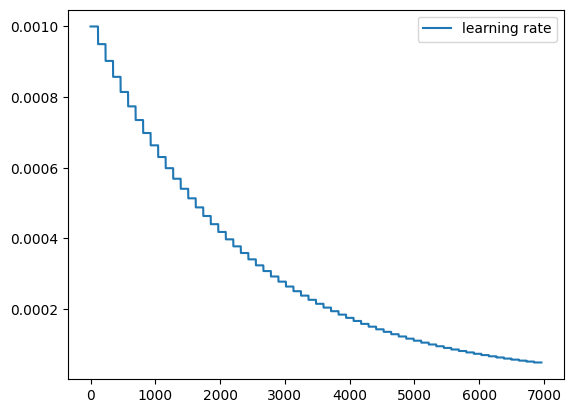

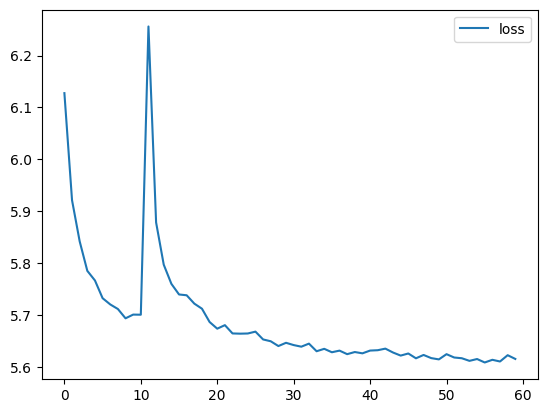

In [9]:
plt.plot(schedule_hist, label='learning rate')
plt.legend()
plt.show()
plt.plot(loss_hist, label = 'loss')
plt.legend()
plt.show()

# Fine-tune the pretrained backbone on the 200 labeled samples


100%|██████████| 2000/2000 [01:21<00:00, 24.52it/s]


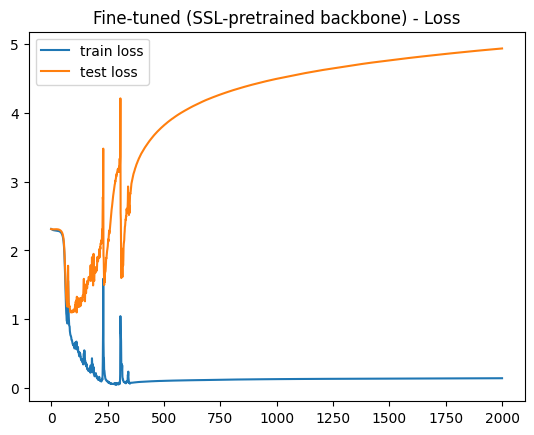

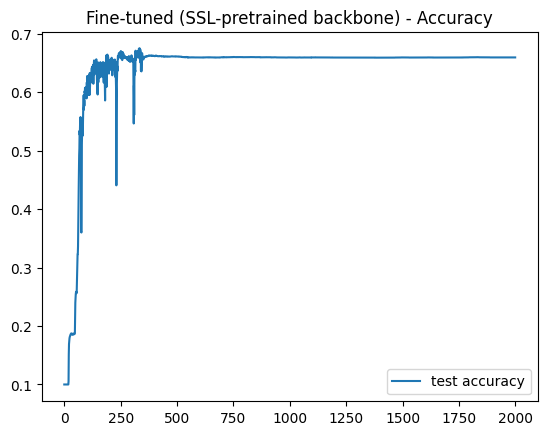

max accuracy (fine-tuned from SSL pretraining): 0.6747


In [10]:
import os
os.makedirs('images', exist_ok=True)

def finetune_pretrained(pretrained_backbone, freeze_backbone=False):
    ft_model = Model().to(device)
    # copy the self-supervised weights into the new model's backbone
    ft_model.backbone.load_state_dict(pretrained_backbone.state_dict())

    if freeze_backbone:
        for p in ft_model.backbone.parameters():
            p.requires_grad = False

    batch_size = 32
    lr = 0.01
    momentum = 0.9
    num_epochs = 2000

    # only optimize params that require grad (matters if freeze_backbone=True)
    optimizer = torch.optim.SGD(
        filter(lambda p: p.requires_grad, ft_model.parameters()),
        lr=lr, momentum=momentum
    )
    loss_fn = torch.nn.CrossEntropyLoss()

    train_hist, test_hist, test_accuracy = [], [], []

    for epoch in tqdm(range(num_epochs)):
        ft_model.train()
        for i in range(int(len(train_x) / batch_size)):
            optimizer.zero_grad()
            X = torch_train_x[i * batch_size: (i + 1) * batch_size]
            y = torch_train_y[i * batch_size: (i + 1) * batch_size]
            y_pred = ft_model(X)
            loss = loss_fn(y_pred, y)
            loss.backward()
            optimizer.step()

        with torch.no_grad():
            ft_model.eval()
            train_loss = loss_fn(ft_model(torch_train_x), torch_train_y).cpu().numpy()
            y_pred_test = ft_model(torch_test_x)
            test_loss = loss_fn(y_pred_test, torch_test_y).cpu().numpy()

            train_hist.append(train_loss)
            test_hist.append(test_loss)

            matches = np.equal(
                np.argmax(y_pred_test.cpu().numpy(), axis=1),
                np.argmax(torch_test_y.cpu().numpy(), axis=1)
            )
            test_accuracy.append(np.mean(matches))

    plt.plot(train_hist, label='train loss')
    plt.plot(test_hist, label='test loss')
    plt.legend()
    plt.title('Fine-tuned (SSL-pretrained backbone) - Loss')
    plt.savefig('images/finetuned_loss.png', dpi=150, bbox_inches='tight')
    plt.show()

    plt.plot(test_accuracy, label='test accuracy')
    plt.legend()
    plt.title('Fine-tuned (SSL-pretrained backbone) - Accuracy')
    plt.savefig('images/finetuned_accuracy.png', dpi=150, bbox_inches='tight')
    plt.show()

    maxacc = np.max(test_accuracy)
    print('max accuracy (fine-tuned from SSL pretraining): {}'.format(maxacc))

    return maxacc, test_accuracy

ssl_maxacc, ssl_test_accuracy = finetune_pretrained(model.backbone, freeze_backbone=False)

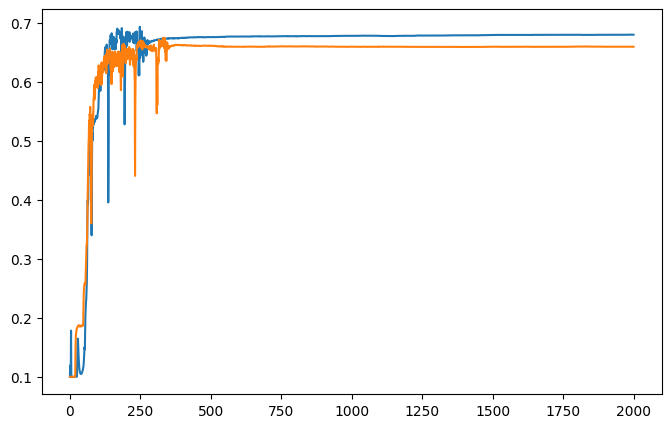

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(supervised_test_accuracy, label='Supervised baseline (200 labeled only)')
plt.plot(ssl_test_accuracy, label='Self-supervised pretrained + fine-tuned')

In [12]:
print('Supervised baseline max accuracy: {}'.format(supervised_maxacc))
print('SSL-pretrained + fine-tuned max accuracy: {}'.format(ssl_maxacc))
print('Improvement: {:.2f} percentage points'.format((ssl_maxacc - supervised_maxacc) * 100))

Supervised baseline max accuracy: 0.6932
SSL-pretrained + fine-tuned max accuracy: 0.6747
Improvement: -1.85 percentage points
